In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Carregar o dataset clássico da UCI
raw_data = load_breast_cancer()
X = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)
y = raw_data.target

# 2. Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Normalização dos dados para Redes Neurais
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter de volta para DataFrame para manter o nome das colunas visíveis
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=raw_data.feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=raw_data.feature_names)

print(f"Dataset carregado! Total de atributos: {X.shape[1]}")
print(f"Classes: {raw_data.target_names} (0 = Maligno, 1 = Benigno)")

Dataset carregado! Total de atributos: 30
Classes: ['malignant' 'benign'] (0 = Maligno, 1 = Benigno)


In [2]:
from sklearn.neural_network import MLPClassifier

# Treinar a Rede Neural 
# 2 camadas ocultas de 15 neurônios cada, 1000 iterações para garantir convergência
mlp_model = MLPClassifier(hidden_layer_sizes=(15, 15), max_iter=1000, random_state=42)
mlp_model.fit(X_train_scaled, y_train)

print(f"Acurácia da Rede Neural (MLP) no teste: {mlp_model.score(X_test_scaled, y_test):.4f}")
print("\n--- Tentando 'olhar' dentro da Caixa-Preta (Pesos da Primeira Camada) ---")

# Mostrar apenas uma fração dos milhares de pesos gerados
pesos_exemplo = mlp_model.coefs_[0][:3, :5] 
print(pesos_exemplo)

Acurácia da Rede Neural (MLP) no teste: 0.9737

--- Tentando 'olhar' dentro da Caixa-Preta (Pesos da Primeira Camada) ---
[[ 0.03635639  0.25202299  0.18193025  0.20917929 -0.33649407]
 [ 0.05689547 -0.44795471  0.10528749  0.25919539 -0.34764304]
 [ 0.19786714 -0.31442282 -0.29148739  0.45928841  0.25524362]]


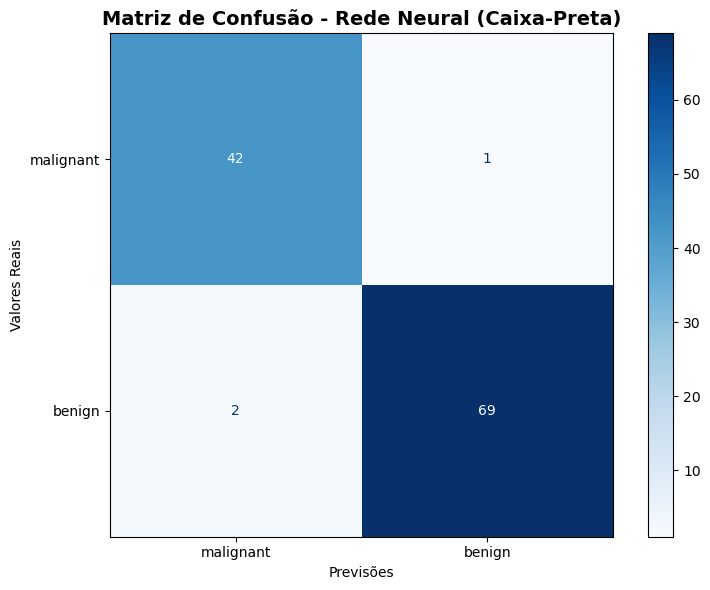


--- Relatório de Classificação ---
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.97        43
      benign       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. Fazer as previsões com o modelo treinado
predictions = mlp_model.predict(X_test_scaled)

# 2. Criar a matriz de confusão
cm = confusion_matrix(y_test, predictions)

# 3. Configurar a visualização da matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=raw_data.target_names)

# 4. Desenhar o gráfico
disp.plot(cmap='Blues', ax=ax)
ax.grid(False)
plt.title("Matriz de Confusão - Rede Neural (Caixa-Preta)", fontsize=14, fontweight='bold')
plt.xlabel("Previsões")
plt.ylabel("Valores Reais")
plt.tight_layout()
plt.savefig("confusion_matrix_mlp.png", dpi=300, bbox_inches='tight')
plt.show()

# 5. Exibir relatório de classificação
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, predictions, target_names=raw_data.target_names))

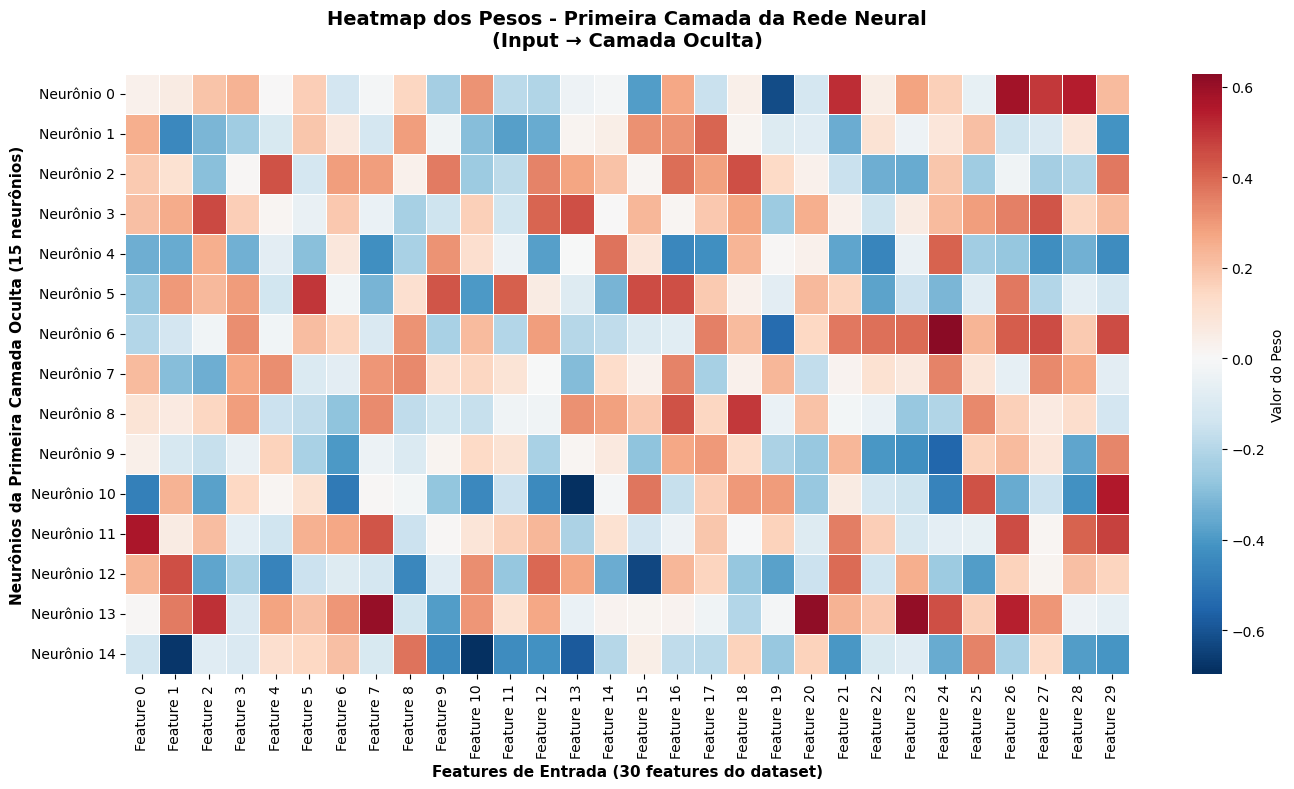

Visualização dos pesos salva como 'pesos_primeira_camada_heatmap.png'
Forma dos pesos: (30, 15) (30 features × 15 neurônios)

Interpretação:
  - Cores AZUIS: pesos positivos (conexão reforça o neurônio)
  - Cores VERMELHAS: pesos negativos (conexão enfraquece o neurônio)
  - Cores CLARAS: pesos próximos de zero (pouca influência)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extrair os pesos da primeira camada (input -> primeira camada oculta)
pesos_primeira_camada = mlp_model.coefs_[0]

# Obter nomes das features de entrada
feature_names = raw_data.feature_names

# Criar figura com tabela de pesos como heatmap
fig, ax = plt.subplots(figsize=(14, 8))

# Criar o heatmap dos pesos
sns.heatmap(pesos_primeira_camada.T, 
            xticklabels=[f'Feature {i}' for i in range(pesos_primeira_camada.shape[0])],
            yticklabels=[f'Neurônio {i}' for i in range(pesos_primeira_camada.shape[1])],
            cmap='RdBu_r',  # Vermelho (negativo) e Azul (positivo)
            center=0,
            annot=False,  # Set True se quiser ver os valores dentro das células
            fmt='.3f',
            cbar_kws={'label': 'Valor do Peso'},
            ax=ax,
            linewidths=0.5)

ax.set_title(
    'Heatmap dos Pesos - Primeira Camada da Rede Neural\n(Input → Camada Oculta)', 
    fontsize=14, fontweight='bold', pad=20
)
ax.set_xlabel('Features de Entrada (30 features do dataset)', fontsize=11, fontweight='bold')
ax.set_ylabel('Neurônios da Primeira Camada Oculta (15 neurônios)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("pesos_primeira_camada_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Visualização dos pesos salva como 'pesos_primeira_camada_heatmap.png'")
print(f"Forma dos pesos: {pesos_primeira_camada.shape} (30 features × 15 neurônios)")
print(f"\nInterpretação:")
print(f"  - Cores AZUIS: pesos positivos (conexão reforça o neurônio)")
print(f"  - Cores VERMELHAS: pesos negativos (conexão enfraquece o neurônio)")
print(f"  - Cores CLARAS: pesos próximos de zero (pouca influência)")